# Why whole-cavity tuning needs field flatness

When you optimise a whole multi-cell cavity you must keep it on frequency. Doing that
with **two** knobs — the shared equator `Req` and the end-cell length `L_e` — is one
constraint in two unknowns, so the solutions form a **continuous family**: infinitely
many `(Req, L_e)` pairs hit the target `f`, and they are *not* the same cavity. The
extra freedom is spent on the **on-axis field**: most family members are tilted, and
only one is field-flat.

This example maps the frequency and the field flatness over `(Req, L_e)`, shows a
handful of family members and their on-axis fields, and locates the flat design. The
punchline is the rule cavsim2d's optimiser follows: **tune each cell to `f`
independently** (mid `Req`, end `L`), which lands on the flat design automatically — so
a whole-cavity optimisation over mid *and* end shape stays flat without a flatness
objective. Only `Req` (all equators) and `L_e` (both end lengths) move here.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()

F = 1300.0                                     # target accelerating frequency [MHz]
NCELLS = 3
A, B, a, b, Ri, L_m = 42, 42, 12, 19, 35, 57.7     # fixed cell shape; L_m = mid length
H = 15                                          # eigenmode mesh size [mm]


def _flatness(e):
    '''Field flatness [%] of an on-axis |Ez|: smallest / largest of the NCELLS tallest
    cell peaks (100% = every cell equal). Used only to check that a saved axis field
    really is the accelerating mode before plotting it.'''
    pk, _ = find_peaks(e, distance=max(1, len(e) // (2 * NCELLS + 1)))
    if len(pk) == 0:
        return np.nan
    tops = np.sort(e[pk])[-NCELLS:]
    return float(tops.min() / tops.max() * 100)


def _solve_once(Req, L_e):
    mid = [A, B, a, b, Ri, L_m, Req]
    end = [A, B, a, b, Ri, L_e, Req]
    cav = EllipticalCavity(NCELLS, mid, end, end, beampipe='both')
    if cav.profile() is None:
        return np.nan, np.nan, None, None
    cav.set_workspace(tempfile.mkdtemp())
    cav.eigenmode.run(mesh_config={'h': H, 'p': 2}, n_modes=NCELLS + 2)
    dfm = cav.eigenmode.qois_df.query('m == 0')
    band = dfm[dfm['freq [MHz]'] < 1.5 * F]
    row = band.loc[band['R/Q [Ohm]'].idxmax()]              # the accelerating (pi) mode
    freq, ff = float(row['freq [MHz]']), float(row['ff [%]'])
    ax_tmp = cav.plot_axis_field(show=False)                # loads the on-axis |Ez|
    z = np.asarray(cav.Ez_0_abs['z(0, 0)'])
    e = np.asarray(cav.Ez_0_abs['|Ez(0, 0)|'])
    plt.close(ax_tmp.figure)
    return freq, ff, z, e


def solve(Req, L_e, axis=False):
    '''Accelerating (highest-R/Q monopole) mode: (freq [MHz], ff [%]); with axis=True
    also the on-axis (z[m], |Ez|). ff is the per-mode QoI; a rare peak-finder miss
    returns ff == 0, so re-solve (fresh mesh) a couple of times if that happens.'''
    freq = ff = z = e = np.nan
    for _ in range(3):
        try:
            freq, ff, z, e = _solve_once(Req, L_e)
        except Exception:
            return (np.nan, np.nan) if not axis else (np.nan, np.nan, None, None)
        if ff and ff > 0 and not np.isnan(ff):
            break
    return (freq, ff) if not axis else (freq, ff, z, e)

## 1. Map frequency and field flatness over the two knobs

One eigenmode solve per grid point gives both the accelerating-mode frequency and the
field flatness `ff` from its on-axis field (100% = every cell peak equal).

In [2]:
req_vals = np.linspace(103.0, 104.3, 5)        # shared equator [mm]
le_vals = np.linspace(55.0, 79.0, 6)           # end-cell length [mm]

Fgrid = np.full((len(req_vals), len(le_vals)), np.nan)
FFgrid = np.full_like(Fgrid, np.nan)
for i, Req in enumerate(req_vals):
    for j, L_e in enumerate(le_vals):
        Fgrid[i, j], FFgrid[i, j] = solve(Req, L_e)
    print('Req=%.2f  ->  f in [%.1f, %.1f] MHz,  ff in [%.0f, %.0f] %%'
          % (Req, np.nanmin(Fgrid[i]), np.nanmax(Fgrid[i]),
             np.nanmin(FFgrid[i]), np.nanmax(FFgrid[i])))
RR, LL = np.meshgrid(req_vals, le_vals, indexing='ij')

Req=103.00  ->  f in [1298.9, 1319.6] MHz,  ff in [44, 89] %


Req=103.33  ->  f in [1294.3, 1315.1] MHz,  ff in [44, 89] %


Req=103.65  ->  f in [1289.7, 1310.7] MHz,  ff in [43, 90] %


Req=103.97  ->  f in [1285.1, 1306.3] MHz,  ff in [43, 90] %


Req=104.30  ->  f in [1280.6, 1302.0] MHz,  ff in [42, 90] %


## 2. The frequency solutions are a continuous family

The white curve is `F_cav = f`. It is a continuous curve, so infinitely many
`(Req, L_e)` pairs hold the operating frequency.

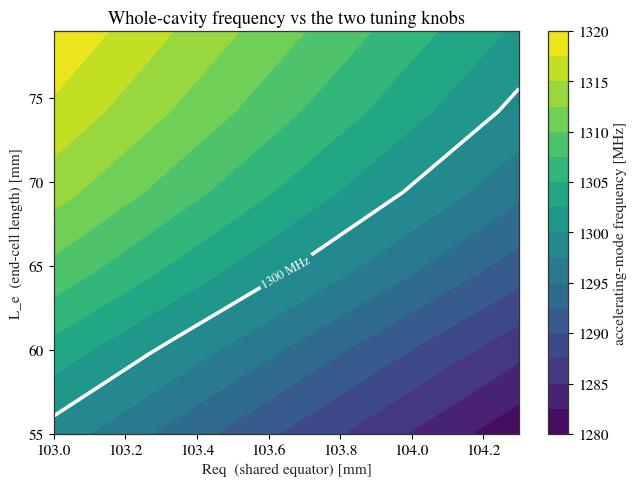

family members (Req, L_e):
   Req=103.000  L_e=56.076
   Req=103.325  L_e=60.531
   Req=103.650  L_e=64.650
   Req=103.975  L_e=69.386
   Req=104.300  L_e=75.572


In [3]:
fig, ax = plt.subplots(figsize=(6.6, 5.0))
cf = ax.contourf(RR, LL, Fgrid, levels=18, cmap='viridis')
cs = ax.contour(RR, LL, Fgrid, levels=[F], colors='white', linewidths=2.6)
ax.clabel(cs, fmt='%.0f MHz', fontsize=9)
plt.colorbar(cf, ax=ax, label='accelerating-mode frequency [MHz]')
ax.set_xlabel('Req  (shared equator) [mm]'); ax.set_ylabel('L_e  (end-cell length) [mm]')
ax.set_title('Whole-cavity frequency vs the two tuning knobs')
plt.tight_layout(); plt.show()

# a handful of family members: for each Req, the L_e that gives f = F (frequency rises
# monotonically with L_e here, so a 1-D interpolation per row is exact).
family_pts = []
for i, Req in enumerate(req_vals):
    fr = Fgrid[i]
    if np.nanmin(fr) <= F <= np.nanmax(fr):
        family_pts.append((Req, float(np.interp(F, fr, le_vals))))
family_pts = np.array(family_pts)
print('family members (Req, L_e):')
for r, l in family_pts:
    print('   Req=%.3f  L_e=%.3f' % (r, l))

## 3. On-axis fields along the family — the profile tilts

Every member runs at `f`, but the on-axis accelerating field is not the same. As we
walk the family, the mid/end balance shifts and the field tilts. Each curve is
normalised to its own peak so the shape is comparable; the flatness `ff` is printed.

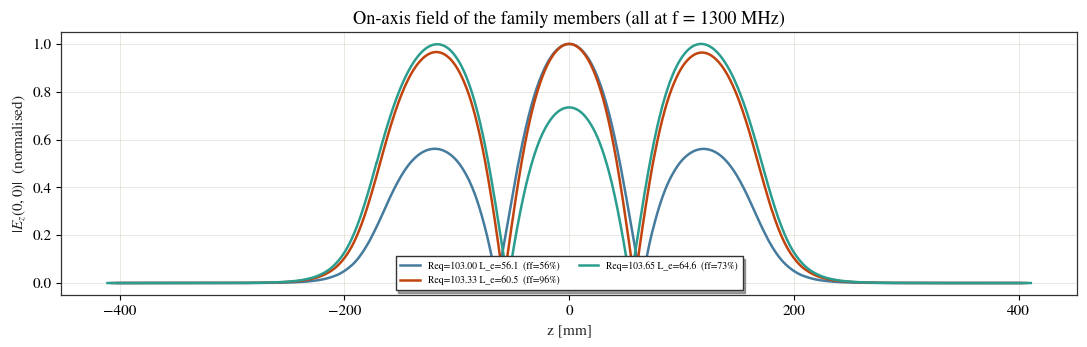

flattest family member: Req=103.325 L_e=60.531  ff=96.4%


,Req,L_e,freq [MHz],ff [%]
0,103.00,56.08,1299.88,56.09
1,103.32,60.53,1300.04,96.39
2,103.65,64.65,1300.00,73.45
3,103.98,69.39,1300.00,56.41
4,104.30,75.57,1300.08,45.32


In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
rows = []
member_fields = {}                          # ff -> (z, e) for the drawn profiles
for r, l in family_pts:
    freq, ff, z, e = solve(r, l, axis=True)
    if z is None:
        continue
    rows.append({'Req': r, 'L_e': l, 'freq [MHz]': freq, 'ff [%]': ff})
    # draw the profile only when the saved field is the accelerating mode itself
    # (the solver stores a single 'mode of interest', which drifts to a nearby mode
    # at extreme tilt); the flatness value in the table is the per-mode QoI regardless.
    if abs(_flatness(e) - ff) < 15:
        ax.plot(z * 1e3, e / e.max(), lw=1.8,
                label='Req=%.2f L_e=%.1f  (ff=%.0f%%)' % (r, l, ff))
        member_fields[ff] = (z, e)
ax.set_xlabel('z [mm]'); ax.set_ylabel('$|E_z(0,0)|$  (normalised)')
ax.set_title('On-axis field of the family members (all at f = %g MHz)' % F)
ax.legend(fontsize=7, loc='lower center', ncol=2)
plt.tight_layout(); plt.show()

fam_df = pd.DataFrame(rows)
flat_member = fam_df.loc[fam_df['ff [%]'].idxmax()]
print('flattest family member: Req=%.3f L_e=%.3f  ff=%.1f%%'
      % (flat_member['Req'], flat_member['L_e'], flat_member['ff [%]']))
fam_df.round(2)

## 4. The field-flat design from per-cell tuning

Now tune the cavity the way cavsim2d does inside a whole-cavity optimisation: a
**two-stage** tune that drives the periodic **mid** cell to `f` with `Req`, then the
reduced **end** cell to `f` with `L` (both ends tied). Two conditions → one
`(Req*, L_e*)`; we check its flatness against the family.

per-cell tuned point:  Req* = 103.3649 mm,  L_e* = 61.0645 mm
  assembled there:  f = 1300.083 MHz,  ff = 98.2 %


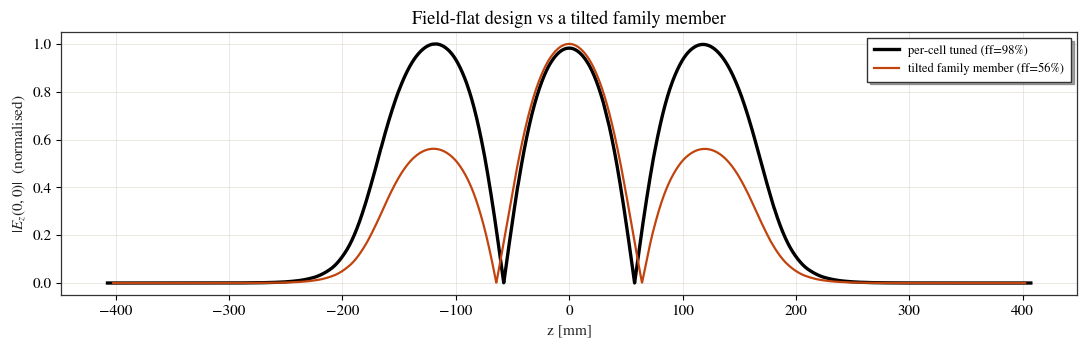

In [5]:
study = Study(os.path.join(tempfile.mkdtemp(), 'tune2'))
mid0 = [A, B, a, b, Ri, L_m, 103.3]
study.add_cavity([EllipticalCavity(NCELLS, mid0, mid0, mid0, beampipe='both', name='cav')], ['cav'])
study.run_tune({'freqs': F, 'processes': 1, 'tol': 2e-2,
                'cell_type': {'mid-cell': 'Req', 'end-cell': 'L'},   # the whole-cavity recipe
                'eigenmode_config': {'processes': 1, 'boundary_conditions': 'mm'}})
tp = study.cavities_list[0].tuned.parameters
Req_star, Le_star = tp['Req_m'], tp['L_el']
f_star, ff_star, z_s, e_s = solve(Req_star, Le_star, axis=True)
print('per-cell tuned point:  Req* = %.4f mm,  L_e* = %.4f mm' % (Req_star, Le_star))
print('  assembled there:  f = %.3f MHz,  ff = %.1f %%' % (f_star, ff_star))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(z_s * 1e3, e_s / e_s.max(), 'k', lw=2.4, label='per-cell tuned (ff=%.0f%%)' % ff_star)
if member_fields:
    tilt_ff = min(member_fields)             # most-tilted member with a clean field (from §3)
    z_t, e_t = member_fields[tilt_ff]
    ax.plot(z_t * 1e3, e_t / e_t.max(), 'C1', lw=1.6,
            label='tilted family member (ff=%.0f%%)' % tilt_ff)
ax.set_xlabel('z [mm]'); ax.set_ylabel('$|E_z(0,0)|$  (normalised)')
ax.set_title('Field-flat design vs a tilted family member'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. Field flatness along the family and over the plane

**Left:** the field flatness *along the frequency family* — it rises to a peak and the
per-cell-tuned design sits right at the maximum. **Right:** the same flatness as a 2-D
map; the frequency family (white) crosses the high-flatness ridge exactly at the tuned
point. Either way, the field-flat, on-frequency design is a single point.

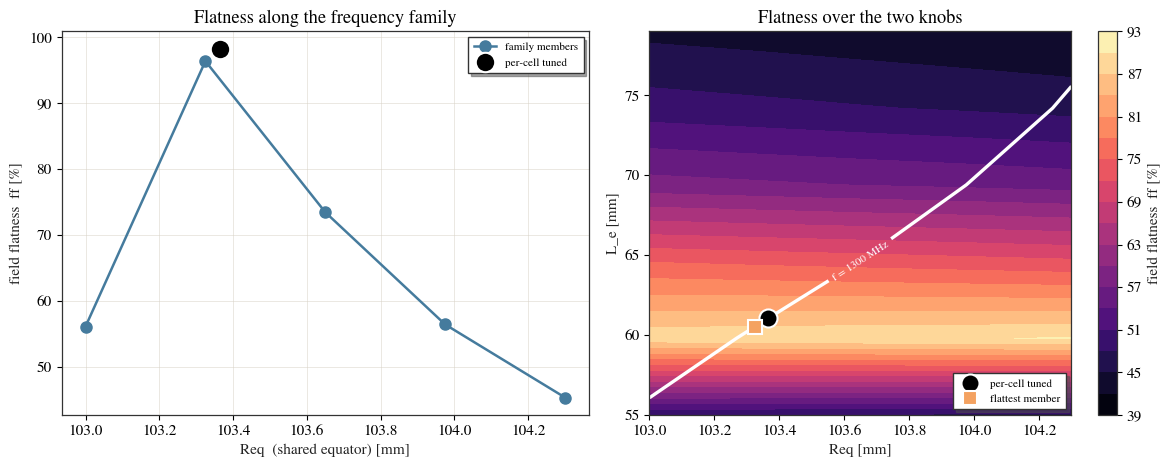

In [6]:
fam_sorted = fam_df.sort_values('Req')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

# left: flatness along the frequency family (vs Req)
ax1.plot(fam_sorted['Req'], fam_sorted['ff [%]'], 'o-', ms=8, color='C0', label='family members')
ax1.plot(Req_star, ff_star, 'o', ms=14, mfc='k', mec='white', mew=1.5, label='per-cell tuned')
ax1.set_xlabel('Req  (shared equator) [mm]'); ax1.set_ylabel('field flatness  ff [%]')
ax1.set_title('Flatness along the frequency family'); ax1.legend(fontsize=8)

# right: flatness over the (Req, L_e) plane, with the family and the special points
cf = ax2.contourf(RR, LL, FFgrid, levels=18, cmap='magma')
cs = ax2.contour(RR, LL, Fgrid, levels=[F], colors='white', linewidths=2.4)
ax2.clabel(cs, fmt='f = %.0f MHz', fontsize=8)
ax2.plot(Req_star, Le_star, 'o', ms=13, mfc='k', mec='white', mew=1.5, label='per-cell tuned')
ax2.plot(flat_member['Req'], flat_member['L_e'], 's', ms=10, mfc='C3', mec='white',
         mew=1.5, label='flattest member')
plt.colorbar(cf, ax=ax2, label='field flatness  ff [%]')
ax2.set_xlabel('Req [mm]'); ax2.set_ylabel('L_e [mm]')
ax2.set_title('Flatness over the two knobs'); ax2.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## What this means for optimisation

- A single frequency constraint with two knobs leaves a **1-parameter family**; §2–§3
  show members that all sit at `f` but with tilted fields (`ff` ranges widely).
- **Per-cell tuning is the second constraint that makes the design unique and flat**:
  §4–§5 show it landing on the flatness ridge where it meets the family.
- So in cavsim2d a **whole-cavity optimisation** over mid *and* end shape tunes each
  cell to `f` — `tune_config={'cell_type': {'mid-cell':'Req','end-cell':'L'}}`, or just
  omit `cell_type` and this is the default. Field flatness comes for free, and need not
  be added as an objective.
- In a **mid-cell or end-cell** optimisation the single cell is already tuned to `f`, so
  flatness is likewise automatic.